## EXPOSITORY NOTEBOOK

This Notebook is meant as an exposition of the key parts of the implemented algorithm. We rewrite here the most important functions in deep_lpbm while importing utility functions. We then generate a random graph and show apply deep_lpbm to it to display graphically the algorithm.


In [ ]:
import deep_lpbm as DL


import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.utils import dense_to_sparse
import matplotlib.pyplot as plt

This is the default configuration of Deep LPBM. Choices regarding METRIC, HIDDEN_LAYERS_GCN and LEARNING_RATE are discussed in the report. To run the algorithm with a different config, it is sufficient to pass as argument a dictionary with as keys the names of the modified variables and as values the desired values, all other variables' values are kept from the default config

In [ ]:
# ---------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------

#input-output
MODE = "assortative" # disassortative, assortative, hub         #in case of synthetic data, only modifies the output directory
DATA_DIR = "data_synthetic/" + MODE# "miscdata"                #input folder
SUBJECT_IDX = 0                                                 #index of subject inside the input folder

#evaluation 
METRIC = "AIC" # AIC, BIC, ICL                      #metric for the choice of number of clusters Q
Q_list = [7,6,5,4,3]                                #values of Q which we will test

#hyperparameters choice
RANDOM_STATE = 42                                   
HIDDEN_LAYERS_GCN = [ 32]
SPLITLAYER = False
MAX_EPOCHS_INIT = 300     # Phase init encodeur (Algorithme 1)
MAX_EPOCHS = 600          # Phase estimation (Algorithme 1)
LEARNING_RATE = 1e-2   # Adam lr=0.01 dans l'article
NUM_SEEDS = 5            # on garde le meilleur ELBO
CLASS_GCN = "GCNEncoder"  #  "GCNEncoder" , 

As encoder we will use the GCN encoder class from PyTorch Geometric, which we found to be the most reliable compared to a manually implemented GCN and a Multi-layers GCN.

In [4]:
from torch_geometric.nn import GCNConv

class GCNEncoder(torch.nn.Module):
    """
    Version PyTorch Geometric du GCN probabiliste.
    - in_feats : dimension des features d’entrée
    - hidden   : dimension de la couche cachée
    - out_mu   : dimension de sortie pour µ
    - out_lv   : dimension de sortie pour logσ²
    """
    def __init__(self, in_feats: int, hidden: int, out_mu: int, out_lv: int):
        super().__init__()
        self.conv1 = GCNConv(in_feats, hidden)
        self.conv_mu = GCNConv(hidden, out_mu)
        self.conv_lv = GCNConv(hidden, out_lv)

    def forward(self, X: torch.Tensor, edge_index: torch.Tensor):
        H = F.relu(self.conv1(X, edge_index))
        mu = self.conv_mu(H, edge_index)
        lv = self.conv_lv(H, edge_index)
        return mu, lv


Initialization is a key step in the algorithm. We first initialize paramteres starting using K-Means, we employ slight regularization to avoid extremes which cause overflow problems in computing log probabilities.

In [ ]:
def init_all_params(A, Q, params, eps=1e-6, tau=1e-16):
    """
    Initialize all apramters for Deep LPBM, returns:

      - eta0       : N×Q KMeans given labeling, with regularization (one-hot + tau)
      - z0         : N×(Q-1) Initial logits (log((C+tau)/(C_last+tau)))
      - Pi0        : Q×Q Initial estimation for blocks, kept in a safe interval
      - Pi_tilde0  : Q×Q unbounded parametes (nn.Parameter), stabilized by Pi0
    """

    device = torch.device(params.get("device", "cpu"))
    N = A.shape[0]
    A_t = torch.tensor(A, dtype=torch.float32, device=device)

    # ===========================
    # 1) KMEANS → labels
    # ===========================
    km = KMeans(n_clusters=Q, n_init="auto", random_state=0).fit(A)
    labels = torch.from_numpy(km.labels_.astype(int)).to(device)

    # ===========================
    # 2) One-hot hard labels, with regularization
    # ===========================
    C = F.one_hot(labels, num_classes=Q).float().to(device)  # shape (N,Q)

    eta0 = C * (1 - (Q-1)*tau) + (1 - C) * tau
    eta0 = eta0 / eta0.sum(dim=1, keepdim=True)  # normalisation simplex

    # ===========================
    # 3) z0 = LOG-RATIOS + stabilization
    # ===========================
    
    denom = eta0[:, [Q-1]] + tau
    numer = eta0[:, :Q-1] + tau
    z0 = torch.log(numer) - torch.log(denom)

    # moderate clamps to avoid explosive values
    z0 = torch.clamp(z0, -8.0, 8.0) 

    # ===========================
    # 4) Soft estimation of Pi0 (SBM-like)
    # ===========================
    Pi0_num = torch.zeros((Q, Q), device=device)
    Pi0_den = torch.zeros((Q, Q), device=device)
    upper_mask = torch.triu(torch.ones(N, N, device=device), diagonal=1)

    for q in range(Q):
        eta_q = eta0[:, q].unsqueeze(1)      # (N,1)
        for r in range(Q):
            eta_r = eta0[:, r].unsqueeze(0)  # (1,N)
            eta_outer = eta_q @ eta_r        # (N,N)

            num = (A_t * eta_outer * upper_mask).sum()
            den = (eta_outer * upper_mask).sum()

            Pi0_num[q, r] = num
            Pi0_den[q, r] = den + eps

    Pi0 = Pi0_num / Pi0_den
    Pi0 = 0.5 * (Pi0 + Pi0.T)

    # regulatization
    Pi0 = Pi0.clamp(0.05, 0.95)

    # ===========================
    # 5) Pi_tilde0 = inverse arctan 
    # ===========================
    Pi_tilde0 = torch.tan(np.pi * (Pi0 - 0.5))

    # convert into nn.Parameter
    Pi_tilde0 = nn.Parameter(Pi_tilde0)

    # ===========================
    # Stockage of parameters
    # ===========================
    params["eta0"]       = eta0
    params["z0"]         = z0
    params["Pi0"]        = Pi0
    params["Pi_tilde0"]  = Pi_tilde0

    return z0


The encoder is initialized to predict the initialized labels $Z^0$. We use mean squared error as loss and Adam as oprimizer. 

In [ ]:
def init_encoder_phase_GCNEncoder(A, Q, params, config, results_dir=None):
    """
    Initialization of encoder phase (with PyTorch Geometric).

    - µ ≈ z₀ (given by KMeans on A)
    - logσ² ≈ log(0.01)

    Record results in results_dir :
        - initial KMeans partition (CSV + histogram)
        - loss curve for the inistialization init_loss.png
    """
    device   = torch.device(params.get("device", "cpu"))
    hidden   = int(params.get("hidden", config['HIDDEN_LAYERS_GCN'][0]))
    init_lr  = float(params.get("init_lr", config['LEARNING_RATE']))
    seed     = int(params.get("seed", config['RANDOM_STATE']))
    tau      = float(params.get("init_tau", 1e-3))

    torch.manual_seed(seed)
    N = A.shape[0]

    if results_dir is not None:
        os.makedirs(results_dir, exist_ok=True)

    # --- Conversion adjacency → edge_index ---
    A_t = torch.tensor(A, dtype=torch.float32, device=device)
    edge_index, _ = dense_to_sparse(A_t)

    # --- Entry features
    X = torch.eye(N, dtype=torch.float32, device=device)

    # ---  GCN model (created once and kept inside params)
    gcn = GCNEncoder(in_feats=N, hidden=hidden, out_mu=Q-1, out_lv=1).to(device)
    

    # --- Optimiser for initialization phase
    opt = torch.optim.Adam(gcn.parameters(), lr=init_lr)
    

    # --- Soft initialization via KMeans ---
    z0 = init_all_params(A, Q, params)
    # Sauvegarde debug
    #DL.save_init_debug_figures(A, eta0, z0, Pi0, Pi_tilde0, results_dir)

    lv_star = torch.full((N, 1), np.log(0.01), dtype=torch.float32, device=device)

    # --- Training loop ---
    loss_history = []
    gcn.train()
    for _ in range(config['MAX_EPOCHS_INIT']):
        opt.zero_grad()

        # passage GCNConv → µ, logσ²
        mu, logvar = gcn(X, edge_index)

        # alignment to the  z₀ and logσ² target
        loss_mu = F.mse_loss(mu, z0)
        loss_lv = F.mse_loss(logvar, lv_star)
        loss = loss_mu + loss_lv
        loss.backward()
        opt.step()

        loss_history.append(float(loss.detach().cpu()))

    last_loss = loss_history[-1] if loss_history else None

    params["gcn"] = gcn
    # --- Record of the loss curve ---
    if results_dir is not None:
        plt.figure()
        plt.plot(loss_history)
        plt.xlabel("Itérations")
        plt.ylabel("Loss (µ, logσ²)")
        plt.title(f"Phase d'initialisation GCN (Q={Q})")
        plt.tight_layout()
        plt.savefig(os.path.join(results_dir, "init_loss.png"))
        plt.close()

    return last_loss


Here we out the training of the Encoder. This is done with gradient descent using the Adam optimizer. We use learning rate of $10^{-2}$ and 32 Hidden layers, as explained in the report.

In [7]:
def train_deep_lpbm_GCNEncoder(A, Q, config, seed=None, results_dir=None):
    """
    Trains a Deep LPBM model with probabilistic GCN Encoder (PyG version).
    """

    if seed is None:
        seed = config['RANDOM_STATE']

    device = torch.device("cpu")
    torch.manual_seed(seed)

    #convert A from dense to edge_index format for PyG
    A_t = torch.tensor(A, dtype=torch.float32, device=device)
    edge_index, _ = dense_to_sparse(A_t)     # (2, E)
    N = A_t.size(0)

    # Features : identity array
    X = torch.eye(N, dtype=torch.float32, device=device)


    #At any point iin the code, this is the best configuration we have found
    best = {"elbo": -np.inf, "eta": None, "Pi": None}


    for s in range(config['NUM_SEEDS']):
        torch.manual_seed(seed + s)


        # Model initialization
        params = {"Q": Q, "seed": seed + s, "device": device,
                  "hidden": config['HIDDEN_LAYERS_GCN'][0] 
                  , "init_lr": config['LEARNING_RATE']}
        init_encoder_phase_GCNEncoder(A, Q, params, config, results_dir)
        gcn = params["gcn"] 


        #  LPBM parameteres
        Pi_tilde = params["Pi_tilde0"]
        
        # we use the Adam optimizer
        opt = torch.optim.Adam(list(gcn.parameters()) + [Pi_tilde], lr=config['LEARNING_RATE'])

        elbo_history = []

        # === Training Phase ===
        gcn.train()
        for _ in range(config['MAX_EPOCHS'] ):
            opt.zero_grad()

            # Passage GCN → µ and logσ²
            mu, logvar = gcn(X, edge_index)

            # Sampling and ELBO computation
            z = DL.reparameterize(mu, logvar)           #sampling through the reparametrization trick
            Pi = DL.unconstrained_Pi_to_Pi(Pi_tilde)    #trasformation from bounded to undounded Pi to use global optimization methods
            P = DL.decoder_prob(z, Pi)                  #computes P such that p_ij = η_i^T Π η_j i.e. the connection probability between i and j
            elbo = DL.elbo_stub(A_t, P, mu, logvar)     #compute the ELBO for this configuration

            # Backpropagation
            loss = -elbo
            loss.backward()
            opt.step()

            elbo_history.append(float(elbo.detach().cpu()))

        # === Evaluation phase ===
        gcn.eval()
        with torch.no_grad():
            mu, logvar = gcn(X, edge_index)
            z = DL.reparameterize(mu, logvar)
            eta = DL.softmax_logits_to_eta(z).cpu().numpy()
            Pi = DL.unconstrained_Pi_to_Pi(Pi_tilde).cpu().numpy()

        last_elbo = elbo_history[-1]
        if last_elbo > best["elbo"]:
            best.update({
                "elbo": last_elbo,
                "eta": eta,
                "Pi": Pi,
                "history": elbo_history
            })

    # === Keeping track of figures ===
    if results_dir is not None:
        DL.save_all_figures(results_dir, best, Q)

    print(f"[Deep LPBM + GCNConv] Q={Q} — ELBO finale : {best['elbo']:.4f}")
    return best

We include the selection of the cluster number $Q$, through AIC as explained in the report. 

In [8]:
def model_selection_over_Q(A, Q_list, config, subject_name="subject", seed=RANDOM_STATE, CLASS_GCN = CLASS_GCN):
    """
    Tries different values of Q and choses the best,
    Creates a directory results/<subject_name>/Q_<Q>/ for each trainign instance.
    """
    if seed is None:
        seed = config['RANDOM_STATE']

    if CLASS_GCN is None:
        CLASS_GCN = config['CLASS_GCN'] 

    results_dir_base = os.path.join("results", subject_name)
    os.makedirs(results_dir_base, exist_ok=True)

    results = []
    AIC_log = []
    for Q in Q_list:
        print(f"\n=== Training for Q = {Q} ===")
        results_dir_Q = os.path.join(results_dir_base, f"Q_{Q}")
        if config['CLASS_GCN']  == "GCN":
            fit = DL.train_deep_lpbm_GCN(A, Q, config, seed=seed, results_dir=results_dir_Q)
        if config['CLASS_GCN']  == "GCNEncoder":
            fit = DL.train_deep_lpbm_GCNEncoder(A, Q, config, seed=seed, results_dir=results_dir_Q)
        
        # collapse éventuel des petits clusters
        eta_collapsed = DL.collapse_small_clusters(fit["eta"], min_size_ratio=0.03)
        fit["eta"] = eta_collapsed

        # recalcul des critères d'information
        AIC, BIC, ICL = DL.compute_AIC_BIC_ICL(A, fit["eta"], fit["Pi"])
        AIC_log.append(AIC)
        fit.update({"Q": Q, "AIC": AIC, "BIC": BIC, "ICL": ICL})
        results.append(fit)

        DL.draw_graph_with_probabilities(A, fit["eta"], show=True, title = f"Predicted partial Memberships for Q={Q}")

        y_hat = fit["eta"].argmax(axis=1)
        DL.draw_graph_hard_clusters(A, y_hat, show=True, title = f"Predicted Labels for Q={Q}")


        # recording of scores
        with open(os.path.join(results_dir_Q, "scores.txt"), "w") as f:
            f.write(f"AIC: {AIC:.3f}\nBIC: {BIC:.3f}\nICL: {ICL:.3f}\nELBO: {fit['elbo']:.3f}\n")

    # Best choice according to AIC
    best = max(results, key=lambda d: d[config['METRIC']])
    best_Q = best["Q"]

    plt.figure(figsize=(6, 4))

    plt.plot(Q_list, AIC_log, marker='o')
    plt.vlines(best_Q, ymin=min(AIC_log), ymax=max(AIC_log),
            color='red', linestyle='--', label='Best Q')

    plt.title("AIC values for each tested Q")
    plt.xlabel("Number of clusters Q")
    plt.ylabel("AIC")
    plt.legend()
    plt.tight_layout()

    os.makedirs(results_dir_base, exist_ok=True)
    plt.savefig(os.path.join(results_dir_base, "AIC_over_Q.png"))
    plt.close()


    return best, results

This is the main function. Here we call it without arguments and control it from the CONFIG cell. 

In [9]:
def Deep_LPBM( config = {} ):


    config_zero = {
        'MODE' : "assortative", 
        'DATA_DIR' : "data_synthetic/assortative" ,
        'RANDOM_STATE' : 42,
        'HIDDEN_LAYERS_GCN' : [ 32 ], 
        'SPLITLAYER' : False,
        'MAX_EPOCHS_INIT' : 300,     # Phase init encodeur (Algorithme 1)
        'MAX_EPOCHS' : 600,          # Phase estimation (Algorithme 1)
        'LEARNING_RATE' : 1e-2 ,   # Adam lr=0.01 dans l'article
        'NUM_SEEDS' : 5,           # on garde le meilleur ELBO
        'CLASS_GCN' : "GCNEncoder",  #  "GCNEncoder" , 
        'SUBJECT_IDX' : 0,
        'METRIC' : "AIC",
        'Q_list' : [3, 4, 5, 6, 7]       }# AIC, BIC, ICL 

    for key in config_zero.keys():
        if key not in config:
            config[key] = config_zero[key]



    # 1. subject selection inside DATA_DIR 
    
    A_filename = f"A_{config['SUBJECT_IDX']:03d}.npy"     
    A_path = os.path.join(config['DATA_DIR'], A_filename) 

    A = np.load(A_path)
    
    subject_name = os.path.splitext(os.path.basename(A_path))[0].replace("A_", "")
    print(f"Sujet sélectionné : {subject_name} dans le dossier {config['DATA_DIR']}")

    # 2. Number of clusters selection 
    Q_list = config['Q_list']
    best, all_results = model_selection_over_Q(A, Q_list, config, subject_name=config['MODE'] + subject_name)

    # 3. Display results of the best model
    print("\n=== Meilleur modèle ===")
    print(f"Q optimal (AIC) : {best['Q']}")
    print(f"AIC : {best['AIC']:.2f}   |   BIC : {best['BIC']:.2f}   |   ICL : {best['ICL']:.2f}")
    print(f"η shape : {best['eta'].shape}   |   Π shape : {best['Pi'].shape}")


    # 4. Hard partition (predicted clusters) 
    y_hat = DL.hard_clusters_from_eta(best["eta"])
    Pi = best['Pi']

    # 5. We look for a y_* file to eventaully validate, in case of synthetic data 
    y_path = os.path.join(config['DATA_DIR'], os.path.basename(A_path).replace("A_", "y_"))
    Pi_path = os.path.join(config['DATA_DIR'], os.path.basename(A_path).replace("A_", "Pi_"))
    eta_path = os.path.join(config['DATA_DIR'], os.path.basename(A_path).replace("A_", "eta_"))
    
    if os.path.exists(y_path):
        print("\n=== Données synthétiques détectées ===")
        y = np.load(y_path).astype(int).ravel()
        K_true = np.unique(y).size
        print(f"Q vrai : {K_true}   |   Q trouvé : {best['Q']}")


        eta_true = np.load(eta_path)
        Pi_true = np.load(Pi_path)

        # 6. Evaluation. We compute and display several similarity measures between the original mdoel and the found model
        DL.evaluate_clustering(     
            y_true=y,
            y_pred=y_hat,
            eta_true=eta_true,
            eta_hat=best["eta"],
            Pi_true=Pi_true,
            Pi_pred=Pi
        )

        # 7. Record of the labeling. Inside here we permute labels so that they are aligned with the original labels
        DL.save_node_assignments(
            y_true=y,
            y_pred=y_hat,
            mapping= DL.best_label_permutation(y, y_hat),    
            subject_name=config['MODE'] + subject_name,
            results_root="results"
        )

        # 8. Record of Pi and of its difference with Pi_true
    
        results_dir = os.path.join("results", config['MODE'] + subject_name)
        os.makedirs(results_dir, exist_ok=True)

        fig_path = os.path.join(results_dir, "Pi_comparison.png")
        DL.save_Pi_comparison(Pi_true, Pi, fig_path)
    else:
        # 9. In case of real data, with no groudn truth
        print("\n=== Données réelles ===")
        print("Aucune vérité terrain disponible.")
        print("Comptages par cluster prédits :", DL.cluster_counts(y_hat))


To test the result, we generate synthetic data and show performance on it. For visualization purposes, we use a low numeber of nodes. we report again the CONFIG cell for clarity.

In [10]:
# ---------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------


MODE = "hub" # disassortative, assortative, hub
DATA_DIR = "data_synthetic/" + MODE# "miscdata" 
RANDOM_STATE = 42
HIDDEN_LAYERS_GCN = [ 32]
SPLITLAYER = False
MAX_EPOCHS_INIT = 300     # Phase init encodeur (Algorithme 1)
MAX_EPOCHS = 600          # Phase estimation (Algorithme 1)
LEARNING_RATE = 1e-2   # Adam lr=0.01 dans l'article
NUM_SEEDS = 5            # on garde le meilleur ELBO
CLASS_GCN = "GCNEncoder"  #  "GCNEncoder" , 
SUBJECT_IDX = 0
METRIC = "AIC" # AIC, BIC, ICL
Q_list = [7,6,5,4,3]

beta 0.7 eps 0
col [(0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0), (1.0, 0.4980392156862745, 0.054901960784313725, 1.0), (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0), (0.8392156862745098, 0.15294117647058825, 0.1568627450980392, 1.0)] lab ['Class 0', 'Class 1', 'Class 2', 'Class 3']


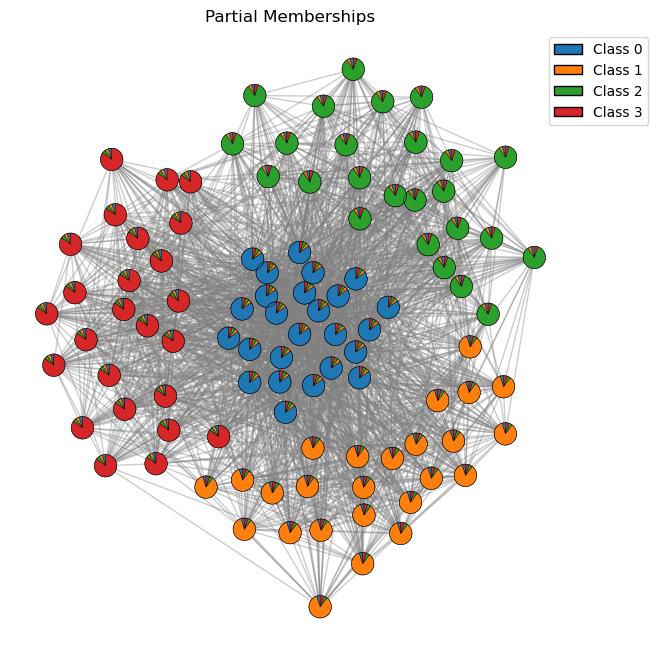

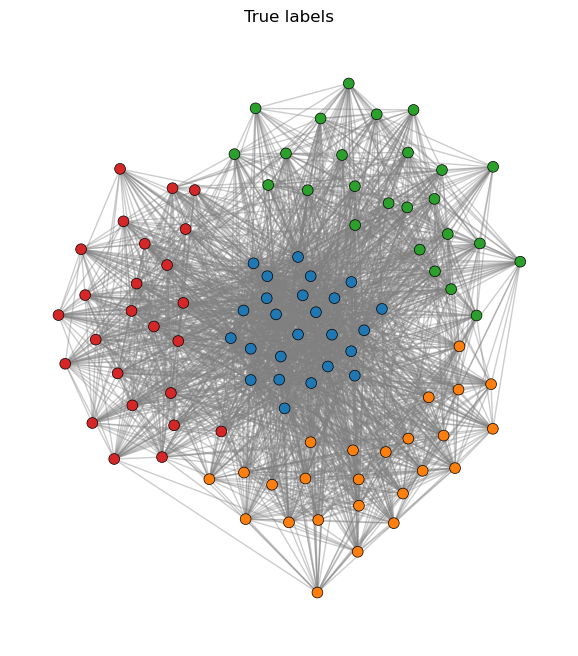

In [11]:
from synthetic_data import generate_synthetic



generate_synthetic(mode=MODE, #disassortative, hub, disassortative
                       outdir="data_synthetic",
                       n_graphs=1,
                       N=100,
                       Q=4,
                       beta=0.7,
                       eps=0,
                       zeta=0.8, # 1 for hard clustering and in (0,1) for partial
                       seed=0)



A_filename = f"A_{SUBJECT_IDX:03d}.npy"     
A_path = os.path.join(DATA_DIR, A_filename) 

A = np.load(A_path)

y_path = os.path.join(DATA_DIR, os.path.basename(A_path).replace("A_", "y_"))
Pi_path = os.path.join(DATA_DIR, os.path.basename(A_path).replace("A_", "Pi_"))
eta_path = os.path.join(DATA_DIR, os.path.basename(A_path).replace("A_", "eta_"))

y = np.load(y_path).astype(int).ravel()
eta_true = np.load(eta_path)
Pi_true = np.load(Pi_path)

DL.draw_graph_with_probabilities(A, eta_true, show = True, title = "Partial Memberships")
DL.draw_graph_hard_clusters(A, y, show=True, title="True labels")

Sujet sélectionné : 000 dans le dossier data_synthetic/hub

=== Training for Q = 3 ===
[Deep LPBM + GCNConv] Q=3 — ELBO finale : -3205.6667
col [(0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0), (1.0, 0.4980392156862745, 0.054901960784313725, 1.0), (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0)] lab ['Class 0', 'Class 1', 'Class 2']


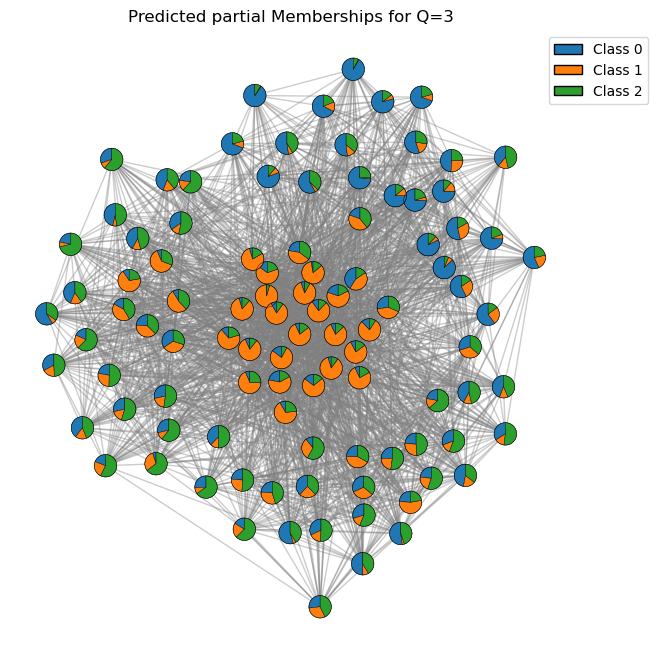

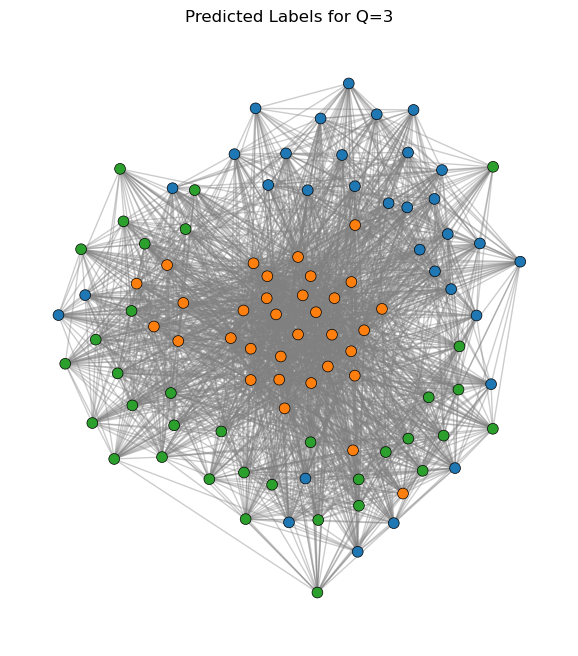


=== Training for Q = 4 ===
[Deep LPBM + GCNConv] Q=4 — ELBO finale : -3233.3940
col [(0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0), (1.0, 0.4980392156862745, 0.054901960784313725, 1.0), (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0), (0.8392156862745098, 0.15294117647058825, 0.1568627450980392, 1.0)] lab ['Class 0', 'Class 1', 'Class 2', 'Class 3']


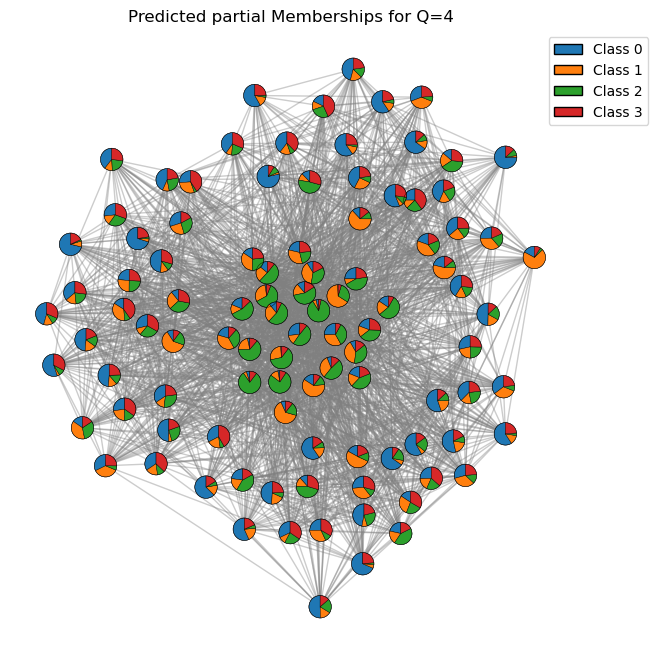

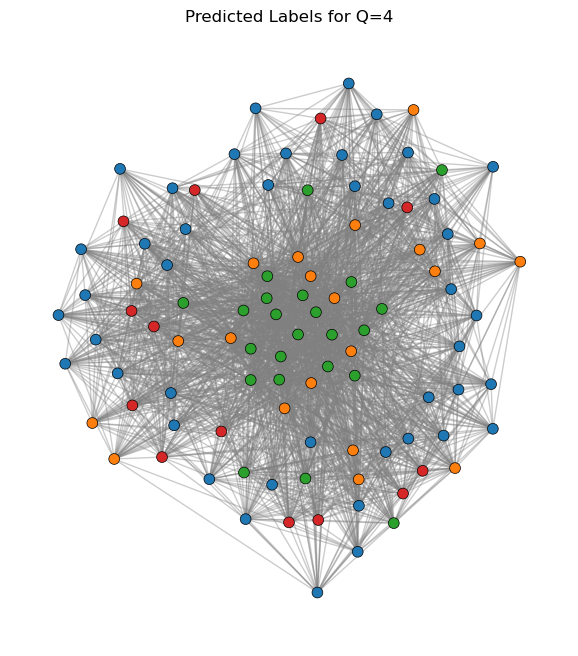


=== Training for Q = 5 ===
[Deep LPBM + GCNConv] Q=5 — ELBO finale : -3101.4404
collapsed!
col [(0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0), (1.0, 0.4980392156862745, 0.054901960784313725, 1.0), (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0), (0.8392156862745098, 0.15294117647058825, 0.1568627450980392, 1.0), (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0)] lab ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4']


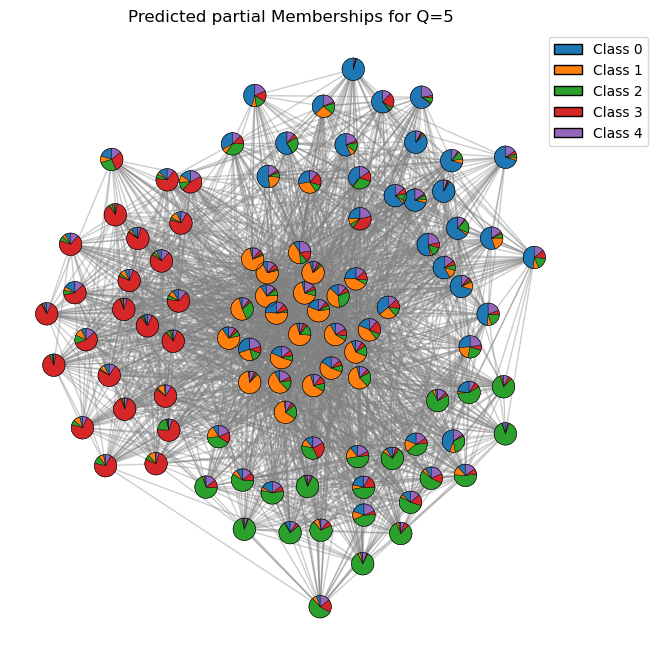

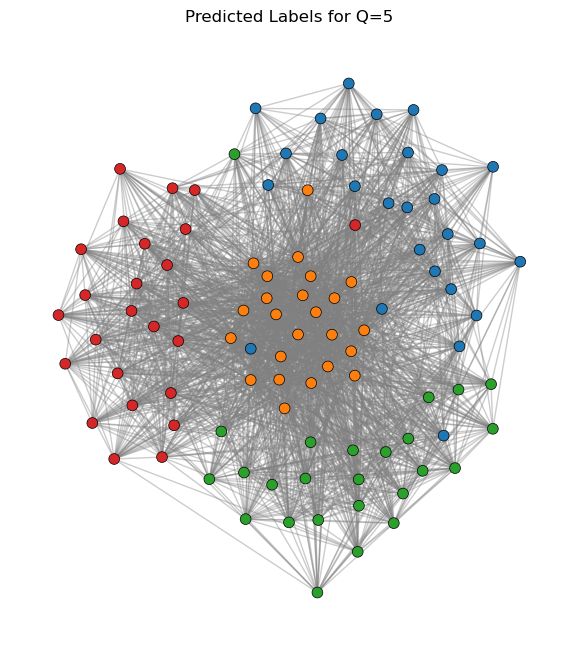


=== Training for Q = 6 ===
[Deep LPBM + GCNConv] Q=6 — ELBO finale : -3268.7419
col [(0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0), (1.0, 0.4980392156862745, 0.054901960784313725, 1.0), (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0), (0.8392156862745098, 0.15294117647058825, 0.1568627450980392, 1.0), (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0), (0.5490196078431373, 0.33725490196078434, 0.29411764705882354, 1.0)] lab ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5']


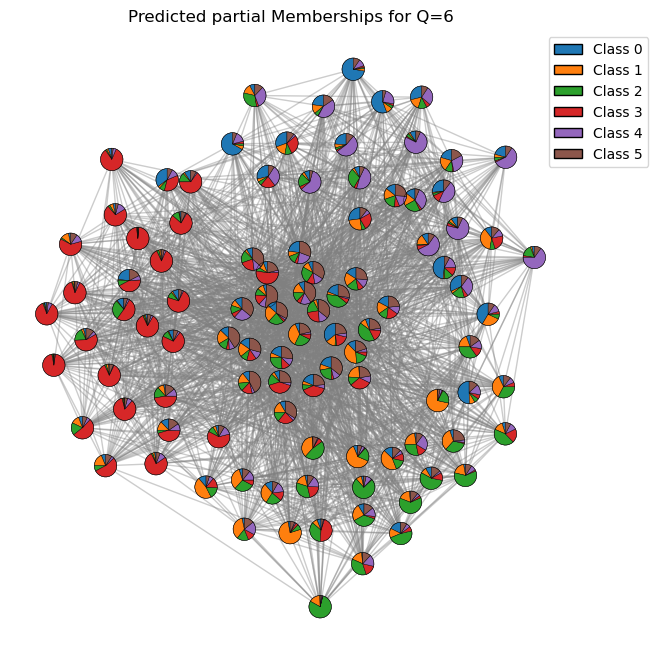

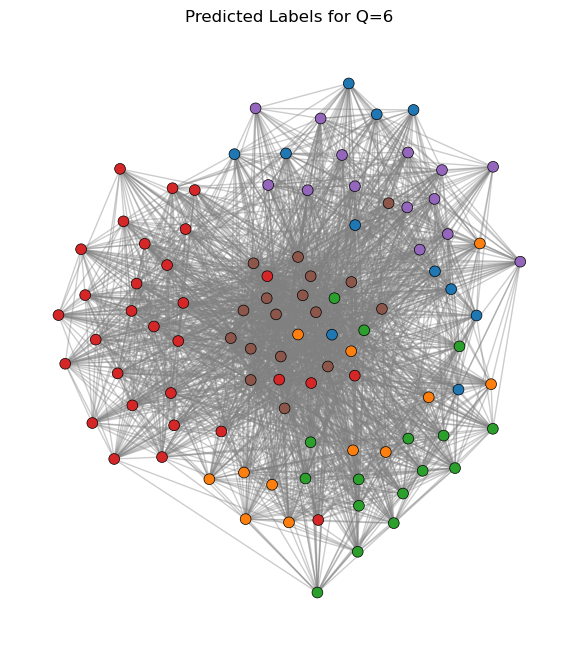


=== Training for Q = 7 ===
[Deep LPBM + GCNConv] Q=7 — ELBO finale : -3198.4446
collapsed!
col [(0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0), (1.0, 0.4980392156862745, 0.054901960784313725, 1.0), (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0), (0.8392156862745098, 0.15294117647058825, 0.1568627450980392, 1.0), (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0), (0.5490196078431373, 0.33725490196078434, 0.29411764705882354, 1.0), (0.8901960784313725, 0.4666666666666667, 0.7607843137254902, 1.0)] lab ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5', 'Class 6']


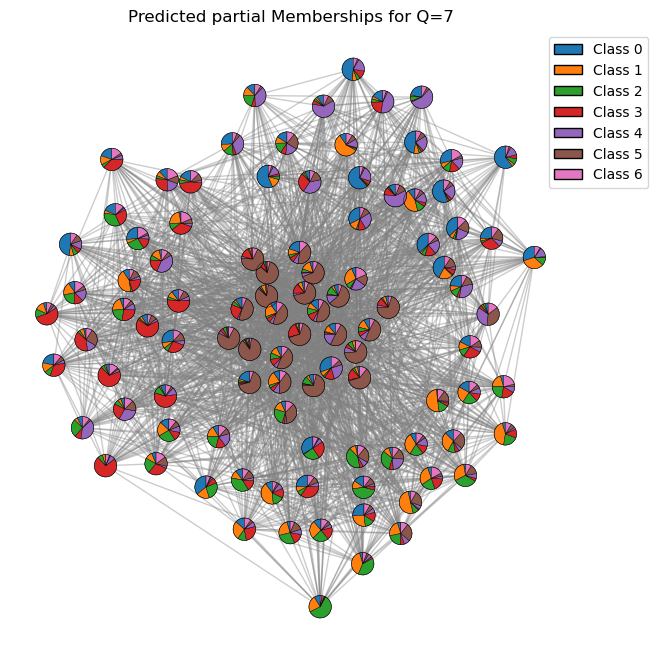

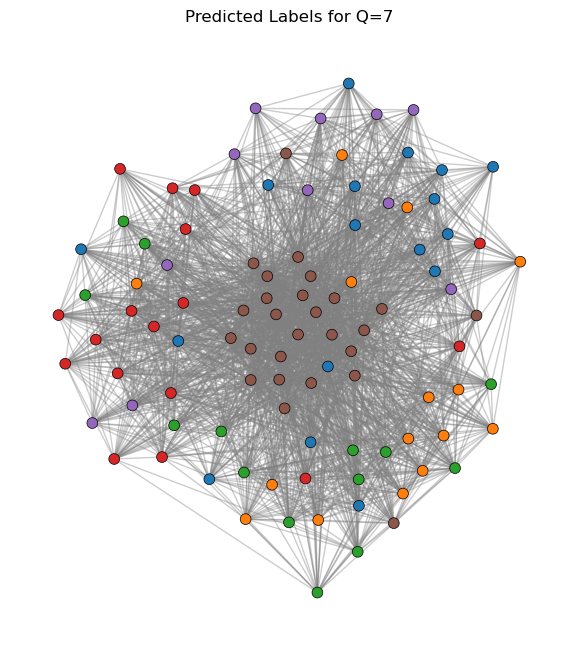


=== Meilleur modèle ===
Q optimal (AIC) : 3
AIC : -3296.43   |   BIC : -3986.19   |   ICL : -3109.96
η shape : (100, 3)   |   Π shape : (3, 3)

=== Données synthétiques détectées ===
Q vrai : 4   |   Q trouvé : 3
=== Évaluation du modèle ===

Score H (appartenances partielles) = 0.4796

=== Matrice de confusion ===
        Pred 0  Pred 1  Pred 2  Pred 3
True 0      25       0       0       0
True 1       2      17       6       0
True 2       1       1      23       0
True 3       5      17       3       0

=== Scores globaux ===
ARI = 0.454
NMI = 0.485
Cluster 0: 25/25 corrects (100.0%)
Cluster 1: 17/25 corrects (68.0%)
Cluster 2: 23/25 corrects (92.0%)
Cluster 3: 0/25 corrects (0.0%)

Assignations enregistrées dans :
  results/hub000/assignments/hub000.json
  results/hub000/assignments/hub000.csv


In [13]:
config = { 'MODE': 'hub', 
    'DATA_DIR': 'data_synthetic/hub' }

Deep_LPBM(config)